<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/Emotion_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Download

In [35]:
import pandas as pd
import re
import gdown


In [36]:
google_drive_link = "https://drive.google.com/file/d/12iVo49pHF7T_tiQRzcF_PDAYCN1rcLLi/view?usp=drive_link"
file_id = re.search(r"/d/(\w+)/", google_drive_link).group(1)
# Define the output file name
output_file = 'fer2013.csv'

In [37]:
# Download the file
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)
# Load the dataset into a Pandas DataFrame
data = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=12iVo49pHF7T_tiQRzcF_PDAYCN1rcLLi
From (redirected): https://drive.google.com/uc?id=12iVo49pHF7T_tiQRzcF_PDAYCN1rcLLi&confirm=t&uuid=c7bf5f4b-a152-40b1-b08d-88e43248e432
To: /content/fer2013.csv
100%|██████████| 301M/301M [00:04<00:00, 68.0MB/s]


### Data Processing

In [38]:
data.head()

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   Usage    35887 non-null  object
 2   pixels   35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


In [40]:
data["Usage"].value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


### Data Preparation

In [41]:
emotions = {0 : "Angry", 1 : "Disgusted", 2 : "Fear", 3 : "Happy", 4 : "Sad", 5 : "Surprised", 6 : "Neutral"}

Prepare data for modeling.

Args:
    data: Data frame with labels and pixel data.
    
Returns:
    image_array: Array of images.
    image_label: Array of image labels.

This function is to transform raw pixel data and labels into a format suitable for machine learning tasks, making it easier to train and evaluate models for emotion detection.

In [42]:
import numpy as np
def prepare_data(data):
    image_array = np.zeros(shape=(len(data), 48, 48))
    image_label = np.array(list(map(int, data['emotion'])))
    for i, row in enumerate(data.index):
        image = np.fromstring(data.loc[row, 'pixels'], dtype=int, sep=' ')
        image = np.reshape(image, (48, 48))
        image_array[i] = image
    return image_array, image_label

In [43]:
train_image_array, train_image_label = prepare_data(data[data["Usage"] == "Training"])
val_image_array, val_image_label = prepare_data(data[data["Usage"] == "PrivateTest"])
test_image_array, test_image_label = prepare_data(data[data["Usage"] == "PublicTest"])

### Reshape and Scale Images

In [44]:
#reshaping the image arrays
train_images = train_image_array.reshape((train_image_array.shape[0], 48, 48, 1))
val_images = val_image_array.reshape((val_image_array.shape[0], 48, 48, 1))
test_images = test_image_array.reshape((test_image_array.shape[0], 48, 48, 1))

In [45]:
#convert pixel values to floating-point numbers and normalize them
train_images = train_images.astype("float32") / 255
val_images = val_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255

### one-hot encode the emotion labels

In [46]:
from keras.utils import to_categorical
#one-hot encode labels
train_labels = to_categorical(train_image_label, num_classes = 7)
val_labels = to_categorical(val_image_label, num_classes = 7)
test_labels = to_categorical(test_image_label, num_classes = 7)



In [47]:
#Calculate class weights for handling imbalanced data in the training dataset.
class_weight = dict(
    zip(
        range(0, 7),  # Emotion labels range from 0 to 6
        (((data[data['Usage']=='Training']['emotion'].value_counts()).sort_index()) /
        len(data[data['Usage']=='Training']['emotion'])).tolist()
    )
)
print(class_weight)

{0: 0.1391549688251071, 1: 0.01518687519593159, 2: 0.14270786164617366, 3: 0.2513149186666202, 4: 0.16823992476226968, 5: 0.11045316799609878, 6: 0.17294228290779895}


### Data Visualization

In [48]:
import matplotlib.pyplot as plt
def plot_all_emotions():
  #create a subplot with 1 row and 7 col, defining the layout of the plot
  fig, axs = plt.subplots(1, 7, figsize = (30, 12))
  fig.subplots_adjust(hspace = .2, wspace = .2)#adjust spacing between subplots
  axs = axs.ravel() #flatten the array for easier iteration


  for i in range(7):
      # Find the index of the first image with the corresponding emotion label (i)
      idx = data[data['emotion'] == i].index[0]
      # Display the image
      axs[i].imshow(train_images[idx][:, :, 0], cmap='gray')
      axs[i].set_title(emotions[train_labels[idx].argmax()])  # Set the title as the emotion name
      axs[i].set_xticklabels([])  # Hide x-axis labels
      axs[i].set_yticklabels([])  # Hide y-axis labels

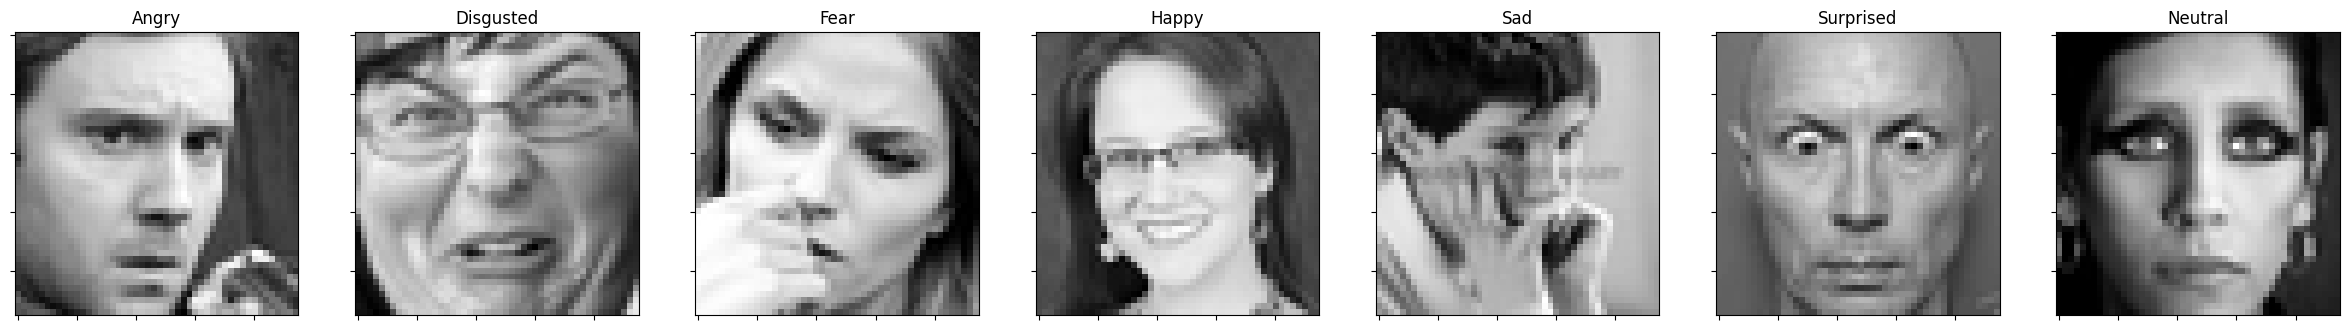

In [49]:
plot_all_emotions()

Visualize example images for a specific emotion label (0-6)

Plot example images for a specified emotion label.

Parameters:
- emotion_label: The emotion label (0-6) for which to display example images.

The function displays five example images corresponding to the specified emotion label.

In [50]:
def plot_emotion(emotion_label=0):
    fig, axs = plt.subplots(1, 5, figsize=(25, 12))
    fig.subplots_adjust(hspace=.2, wspace=.2)  # Adjust spacing between subplots
    axs = axs.ravel()  # Flatten the array for easier iteration
    for i in range(5):
        # Find the index of the ith image with the specified emotion label
        idx = data[data['emotion'] == emotion_label].index[i]
        # Display the image
        axs[i].imshow(train_images[idx][:, :, 0], cmap='gray')
        axs[i].set_title(emotions[train_labels[idx].argmax()])  # Set the title as the emotion name
        axs[i].set_xticklabels([])  # Hide x-axis labels
        axs[i].set_yticklabels([])  # Hide y-axis labels


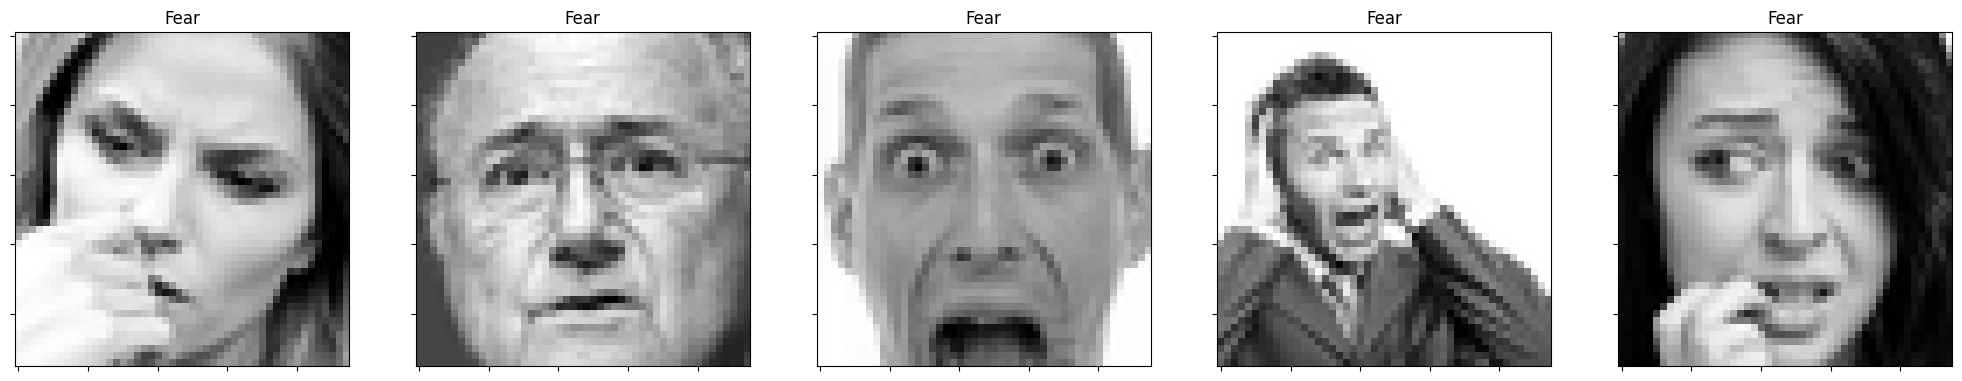

In [51]:
plot_emotion(emotion_label = 2)

Compare and plot the distributions of emotion labels in multiple datasets

Parameters:
- arrays: A list of datasets with one-hot encoded emotion labels.
- colors: A list of colors for the plots.
- titles: A list of titles for each dataset's distribution plot.

In [52]:
import random
def plot_distributions(arrays, colors, titles):
    fig, axs = plt.subplots(1, len(arrays), figsize=(6 * len(arrays), 6), sharey=False)
    fig.subplots_adjust(hspace=0.2, wspace=0.2)
    axs = axs.ravel()
    x = emotions.values()
    for i, array in enumerate(arrays):
        df_array = pd.DataFrame()
        df_array['emotion'] = array.argmax(axis=1)
        y = df_array['emotion'].value_counts()
        keys_missed = list(set(emotions.keys()).difference(set(y.keys())))
        for key_missed in keys_missed:
            y[key_missed] = 0
        axs[i].bar(x, y.sort_index(), color=colors[i])
        axs[i].set_title(titles[i])
        axs[i].grid()

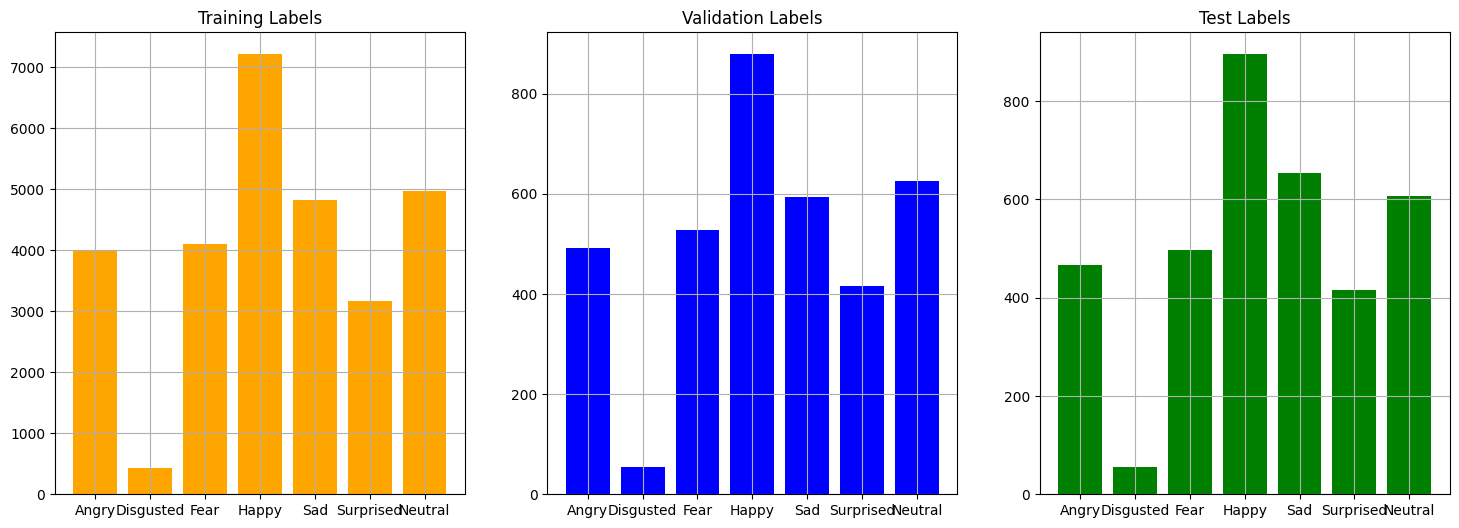

In [53]:
arrays = [train_labels, val_labels, test_labels]
colors = ["orange","blue", "green"]
titles = ["Training Labels", "Validation Labels", "Test Labels"]
plot_distributions(arrays, colors, titles)
plt.show()

### Model Training

In [54]:
from keras import models
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
# Initialize a sequential model
model = models.Sequential()
# Add the first convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
# Add a max-pooling layer
model.add(MaxPool2D((2, 2)))
# Add the second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
# Add another max-pooling layer
model.add(MaxPool2D((2, 2)))
# Add the third convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
# Add another max-pooling layer
model.add(MaxPool2D((2, 2)))
# Add the fourth convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
# Flatten the output from convolutional layers
model.add(Flatten())
# Add a fully connected layer with ReLU activation
model.add(Dense(64, activation='relu'))
# Add the output layer for multi-class classification
model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
# Compile the model with the Adam optimizer, categorical cross-entropy loss, and accuracy metric.
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [56]:
#display a summary of the CNN model's architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,575 (428.03 KB)

 Trainable params: 109,575 (428.03 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Train the CNN model using the training data and validate it with the validation data.
# The model is trained for a specified number of epochs.
# Class weights are used to handle imbalanced datasets.
history = model.fit(
    train_images, train_labels,  # Training data and labels
    validation_data=(val_images, val_labels),  # Validation data for evaluating model performance
    class_weight=class_weight,  # Class weights for handling imbalanced data
    epochs=12,  # Number of training epochs
    batch_size=32  # Number of samples used in each training iteration
)

Epoch 1/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2962 - loss: 0.2745 - val_accuracy: 0.3926 - val_loss: 1.5986
Epoch 2/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4353 - loss: 0.2249 - val_accuracy: 0.4316 - val_loss: 1.5179
Epoch 3/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4883 - loss: 0.2045 - val_accuracy: 0.4909 - val_loss: 1.3673
Epoch 4/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5208 - loss: 0.1924 - val_accuracy: 0.4946 - val_loss: 1.3471
Epoch 5/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5458 - loss: 0.1828 - val_accuracy: 0.5065 - val_loss: 1.3187
Epoch 6/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5614 - loss: 0.1752 - val_accuracy: 0.5308 - val_loss: 1.2495
Epoch 7/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5808 - loss: 0.1685 - val_accuracy: 0.5286 - val_loss: 1.2420
Epoch 8/12
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5947 - loss: 0.1624 - val_accuracy: 0

### Model Evaluation

In [58]:
# Evaluate the model on the test dataset and get test loss and accuracy
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
# Predict the labels for test images
pred_test_labels  = model.predict(test_images)
# Print the test accuracy
print('Test accuracy:', test_accuracy)
print('Test loss:', test_loss)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5517 - loss: 1.2968
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test accuracy: 0.5516856908798218
Test loss: 1.2968014478683472


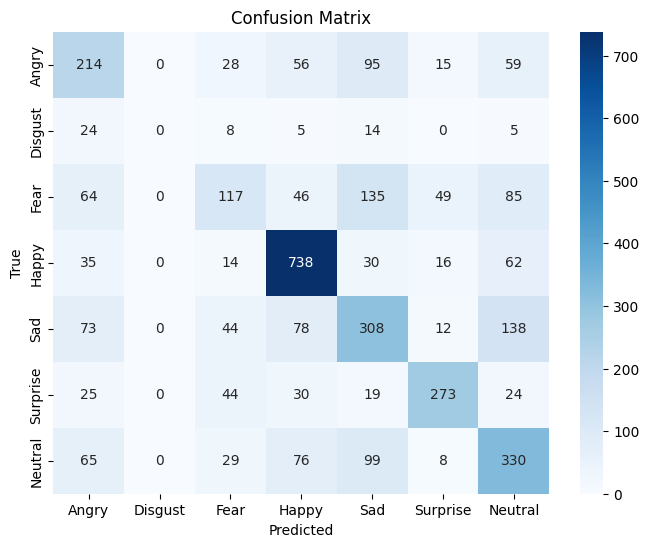

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Get the true labels from the test dataset
true_labels = test_image_label
# Get the predicted labels from the model's predictions
predicted_labels = np.argmax(pred_test_labels , axis=1)
# Create the confusion matrix
matrix = confusion_matrix(true_labels, predicted_labels)
# Define emotion labels for visualization
emotion_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

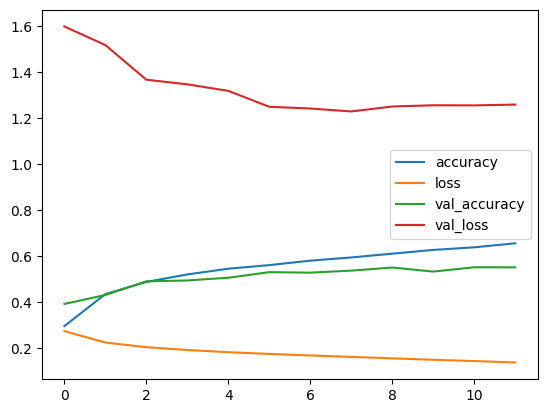

In [60]:
# Plotting training history for various metrics
for key in history.history.keys():
    # Loop through available metrics
    plt.plot(history.history[key], label=key)  # Plot the metric values
plt.legend()  # Add a legend to the plot